In [ ]:
!pip install wfdb

In [ ]:
import wfdb

# Descargar un registro (ej: 100)
record = wfdb.rdrecord('e0103', pn_dir='edb')

# Read a WFDB anno tation file record_name.extension and return an Annotation
annotation = wfdb.rdann('e0103', 'atr', pn_dir='edb')

# Tipo: numpy array
# Forma: (N, canales)
signal = record.p_signal
fs = record.fs

In [ ]:
# https://archive.physionet.org/physiobank/database/records.shtml
# recordx = wfdb.rdrecord('118e00', pn_dir='nstdb')
# signalx = recordx.p_signal
# plt.plot(signalx[:2000,0])

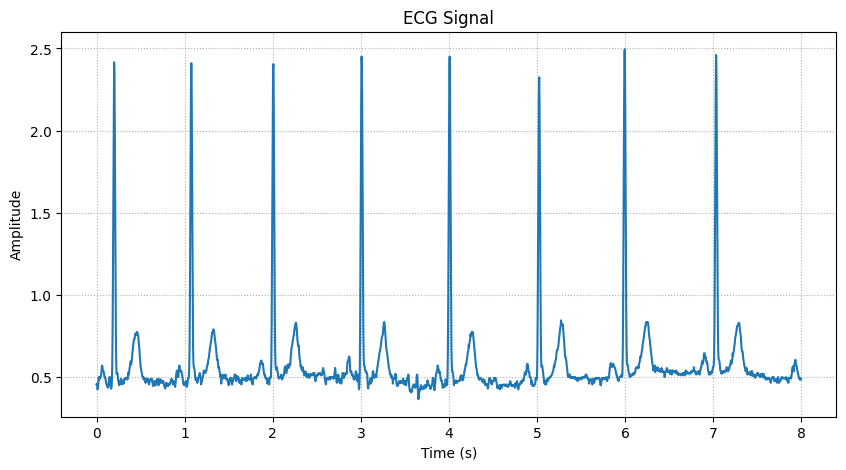

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

N = signal.shape[0]
n = np.arange(N)
t = n/fs

plt.figure(figsize=(10,5))
plt.plot(t[:2000], signal[:2000,0])
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

(array([5.67882260e-01, 2.84375156e-01, 7.93520746e-04, ...,
        7.44656934e-06, 2.47440103e-04, 4.95887162e-04]),
 array([0.00000000e+00, 1.38888889e-04, 2.77777778e-04, ...,
        1.24999722e+02, 1.24999861e+02, 1.25000000e+02]),
 <matplotlib.lines.Line2D at 0x7b34c18b0200>)

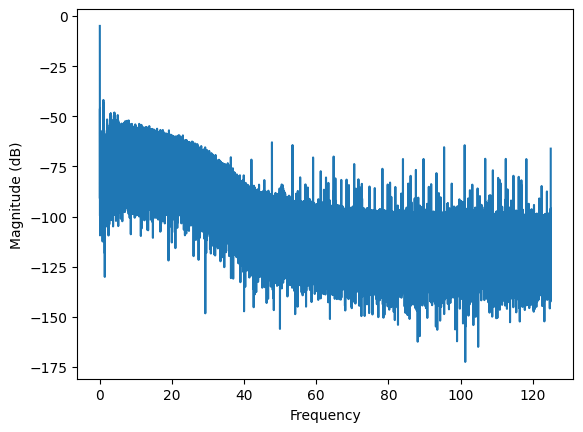

In [ ]:
x = signal[:,0]

plt.magnitude_spectrum(x, Fs=fs, scale='dB')

(array([4.74946500e-04, 1.27628085e-03, 7.93420901e-04, ...,
        7.44656934e-06, 2.47440103e-04, 4.95887162e-04]),
 array([0.00000000e+00, 1.38888889e-04, 2.77777778e-04, ...,
        1.24999722e+02, 1.24999861e+02, 1.25000000e+02]),
 <matplotlib.lines.Line2D at 0x7b34c1835c70>)

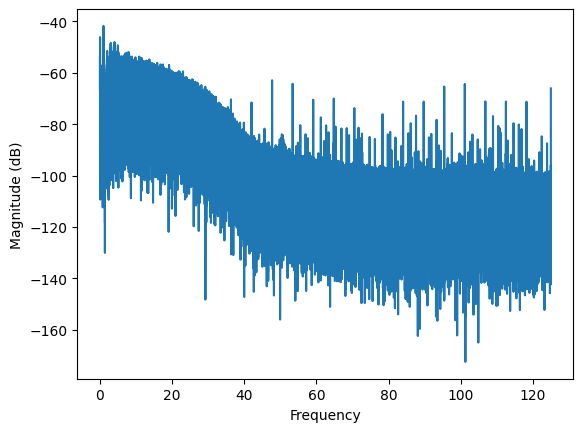

In [ ]:
x_dc_removed = x - np.mean(x)

plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')

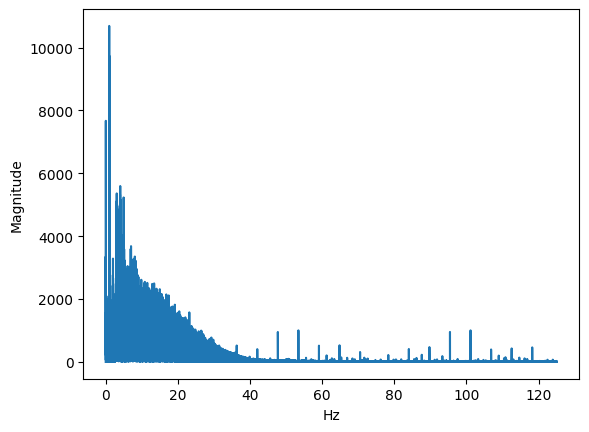

In [ ]:
X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)

plt.plot(freqs[:len(x_dc_removed)//2], np.abs(X[:len(x_dc_removed)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

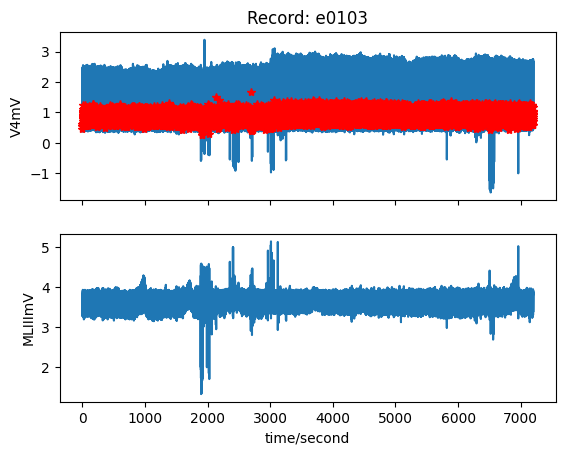

In [ ]:
wfdb.plot_wfdb(record=record, annotation=annotation)